In [1]:
import torch
from torchvision import transforms

from sklearn.metrics import f1_score, confusion_matrix, classification_report
import seaborn as sns


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


PARTE 2: PREPARACIÓN DATASET

In [3]:
# transformaciones para entrenamiento

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# transformaciones para validación y test
transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

PARTE 3: CARGAR EL DATASET

In [4]:

import os
from google.colab import drive


ruta = '/content/drive/MyDrive/oddData'

# Check if the directory exists
if not os.path.exists(ruta):
    print(f"Error: The directory '{ruta}' does not exist.")
    print("Please make sure you have mounted Google Drive and that the path to your 'fotos_AAA' folder is correct.")
    # Initialize files as an empty list to prevent further errors if the directory is not found
    files = []
else:
    files = os.listdir(ruta)
    print(f"Total imágenes: {len(files)}'")
    print('Primeros 10: ')
    for f in files[:10]:
        print(f)

Total imágenes: 4'
Primeros 10: 
.DS_Store
val
train
test


In [5]:
from torchvision import datasets
from torch.utils.data import DataLoader


class ImageFolder(datasets.ImageFolder):
  def __getitem__(self, index):
    try:
      return super(ImageFolder, self).__getitem__(index)
    except:
      return self.__getitem__(index + 1)

# Load pre-split datasets from subfolders
train_dataset = ImageFolder(f"{ruta}/train", transform=transform_train)
val_dataset = ImageFolder(f"{ruta}/val", transform=transform_val)
test_dataset = ImageFolder(f"{ruta}/test", transform=transform_val)

print(f"Total imágenes en train: {len(train_dataset)}")
print(f"Total imágenes en val: {len(val_dataset)}")
print(f"Total imágenes en test: {len(test_dataset)}")

classes = train_dataset.classes # Define 'classes' variable from one of the datasets
print(f"Clases: {classes}")


Total imágenes en train: 2439
Total imágenes en val: 520
Total imágenes en test: 528
Clases: ['cups', 'forks', 'glasses', 'knives', 'plates', 'spoons']


PARTE 4: CARGAR DATOS

In [6]:
train_loader = DataLoader(train_dataset, batch_size = 16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size = 16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle=False)

print(f"Batches en train: {len(train_loader)}")
print(f"Batches en val: {len(val_loader)}")
print(f"Batches en test: {len(test_loader)}")


Batches en train: 153
Batches en val: 33
Batches en test: 33


PARTE 5: ARQUITECTURA CNN

In [7]:
import torch.nn as nn
from torchvision import models

# ============================================================
# ARQUITECTURA: ResNet50 PREENTRENADO (Transfer Learning)
# ============================================================

# Cargar ResNet50 con pesos preentrenados en ImageNet
modelo = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Congelar todos los parámetros del backbone
for param in modelo.parameters():
    param.requires_grad = False

# Reemplazar la capa final (fc) para 6 clases
num_features = modelo.fc.in_features  # 2048
modelo.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 6)
)

print('✓ ResNet50 preentrenado cargado')
print(f'  Backbone: congelado (pesos de ImageNet)')
print(f'  Clasificador final: {num_features} → 256 → 6 clases')
print(f'  Parámetros entrenables: {sum(p.numel() for p in modelo.parameters() if p.requires_grad):,}')
print(f'  Parámetros totales:     {sum(p.numel() for p in modelo.parameters()):,}')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 174MB/s]


✓ ResNet50 preentrenado cargado
  Backbone: congelado (pesos de ImageNet)
  Clasificador final: 2048 → 256 → 6 clases
  Parámetros entrenables: 526,086
  Parámetros totales:     24,034,118


In [8]:
# vamos a probar que la red funciona con el tamaño de la imágenes

imagen_prueba = torch.randn(1, 3, 224, 224)
with torch.no_grad():
  salida = modelo(imagen_prueba)

print(imagen_prueba.shape)
print(salida.shape)
print(classes)

torch.Size([1, 3, 224, 224])
torch.Size([1, 6])
['cups', 'forks', 'glasses', 'knives', 'plates', 'spoons']


PARTE 6: ENTRENAMIENTO

In [9]:
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
modelo = modelo.to(device)

# Solo optimizar los parámetros del clasificador (fc)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, modelo.parameters()),
    lr=1e-3
)

# Scheduler: reducir LR si val_loss no mejora
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

criterio = nn.CrossEntropyLoss()
epochs = 20

hist_loss_train = []
hist_acc_train = []
hist_loss_val = []
hist_acc_val = []

for epoch in range(epochs):
    print(f"  → Epoch {epoch+1} iniciada")
    # ENTRENAMIENTO
    modelo.train()
    loss_total_train = 0
    correctas_train = 0
    total_train = 0

    for imagenes, etiquetas in train_loader:
        imagenes = imagenes.to(device)
        etiquetas = etiquetas.to(device)

        optimizer.zero_grad()
        salida = modelo(imagenes)
        loss = criterio(salida, etiquetas)
        loss.backward()
        optimizer.step()

        loss_total_train += loss.item()
        _, predicciones_train = torch.max(salida, 1)
        correctas_train += (predicciones_train == etiquetas).sum().item()
        total_train += etiquetas.size(0)

    loss_medio_train = loss_total_train / len(train_loader)
    acc_train = correctas_train / total_train

    # VALIDACIÓN
    modelo.eval()
    correctas_val = 0
    total_val = 0
    loss_total_val = 0

    with torch.no_grad():
        for imagenes, etiquetas in val_loader:
            imagenes = imagenes.to(device)
            etiquetas = etiquetas.to(device)
            salida = modelo(imagenes)
            loss_val = criterio(salida, etiquetas)
            loss_total_val += loss_val.item()
            _, predicciones_val = torch.max(salida, 1)
            correctas_val += (predicciones_val == etiquetas).sum().item()
            total_val += etiquetas.size(0)

    loss_medio_val = loss_total_val / len(val_loader)
    acc_val = correctas_val / total_val

    scheduler.step(loss_medio_val)

    hist_loss_train.append(loss_medio_train)
    hist_acc_train.append(acc_train)
    hist_loss_val.append(loss_medio_val)
    hist_acc_val.append(acc_val)

    print(f'Epoch: {epoch+1}/{epochs}')
    print(f'Loss train: {loss_medio_train:.4f} | Acc train: {acc_train:.4f}')
    print(f'Loss val:   {loss_medio_val:.4f} | Acc val:   {acc_val:.4f}')

  → Epoch 1 iniciada
Epoch: 1/20
Loss train: 1.0277 | Acc train: 0.6076
Loss val:   0.5291 | Acc val:   0.8462
  → Epoch 2 iniciada
Epoch: 2/20
Loss train: 0.6676 | Acc train: 0.7626
Loss val:   0.4121 | Acc val:   0.8962
  → Epoch 3 iniciada
Epoch: 3/20
Loss train: 0.5372 | Acc train: 0.8065
Loss val:   0.3787 | Acc val:   0.8635
  → Epoch 4 iniciada
Epoch: 4/20
Loss train: 0.5228 | Acc train: 0.8102
Loss val:   0.3649 | Acc val:   0.8865
  → Epoch 5 iniciada
Epoch: 5/20
Loss train: 0.4835 | Acc train: 0.8237
Loss val:   0.2960 | Acc val:   0.9096
  → Epoch 6 iniciada
Epoch: 6/20
Loss train: 0.4949 | Acc train: 0.8270
Loss val:   0.3383 | Acc val:   0.8827
  → Epoch 7 iniciada
Epoch: 7/20
Loss train: 0.4662 | Acc train: 0.8360
Loss val:   0.2893 | Acc val:   0.8962
  → Epoch 8 iniciada
Epoch: 8/20
Loss train: 0.4485 | Acc train: 0.8421
Loss val:   0.2932 | Acc val:   0.8923
  → Epoch 9 iniciada
Epoch: 9/20
Loss train: 0.4288 | Acc train: 0.8454
Loss val:   0.2757 | Acc val:   0.9019
 

In [10]:

# EVALUACIÓN FINAL EN TEST SET
print("\n" + "="*60)
print("EVALUACIÓN EN TEST SET")
print("="*60 + "\n")

modelo.eval()
correctas_test = 0
total_test = 0
todas_predicciones_test = []
todas_etiquetas_test = []

with torch.no_grad():
    for imagenes, etiquetas in test_loader:
        imagenes = imagenes.to(device)
        etiquetas = etiquetas.to(device)

        salida = modelo(imagenes)
        _, predicciones = torch.max(salida, 1)

        correctas_test += (predicciones == etiquetas).sum().item()
        total_test += etiquetas.size(0)

        todas_predicciones_test.extend(predicciones.cpu().numpy())
        todas_etiquetas_test.extend(etiquetas.cpu().numpy())

# Calcular métricas finales
acc_test = correctas_test / total_test
f1_test = f1_score(todas_etiquetas_test, todas_predicciones_test, average='macro')

print(f"Test Accuracy:     {acc_test:.4f}")
print(f"Test Macro F1-Score: {f1_test:.4f}")

# Classification Report detallado
print("\n" + "="*60)
print("CLASSIFICATION REPORT (TEST SET)")
print("="*60)
print(classification_report(todas_etiquetas_test, todas_predicciones_test,
                          target_names=classes, digits=4))

print("\n✓ Evaluación en test completada")


EVALUACIÓN EN TEST SET

Test Accuracy:     0.8769
Test Macro F1-Score: 0.8760

CLASSIFICATION REPORT (TEST SET)
              precision    recall  f1-score   support

        cups     0.8416    0.8763    0.8586        97
       forks     0.8714    0.7722    0.8188        79
     glasses     0.9080    0.8778    0.8927        90
      knives     0.8404    0.8778    0.8587        90
      plates     0.9643    0.8901    0.9257        91
      spoons     0.8478    0.9630    0.9017        81

    accuracy                         0.8769       528
   macro avg     0.8789    0.8762    0.8760       528
weighted avg     0.8793    0.8769    0.8766       528


✓ Evaluación en test completada


### PARTE 7: Visualización de los Resultados

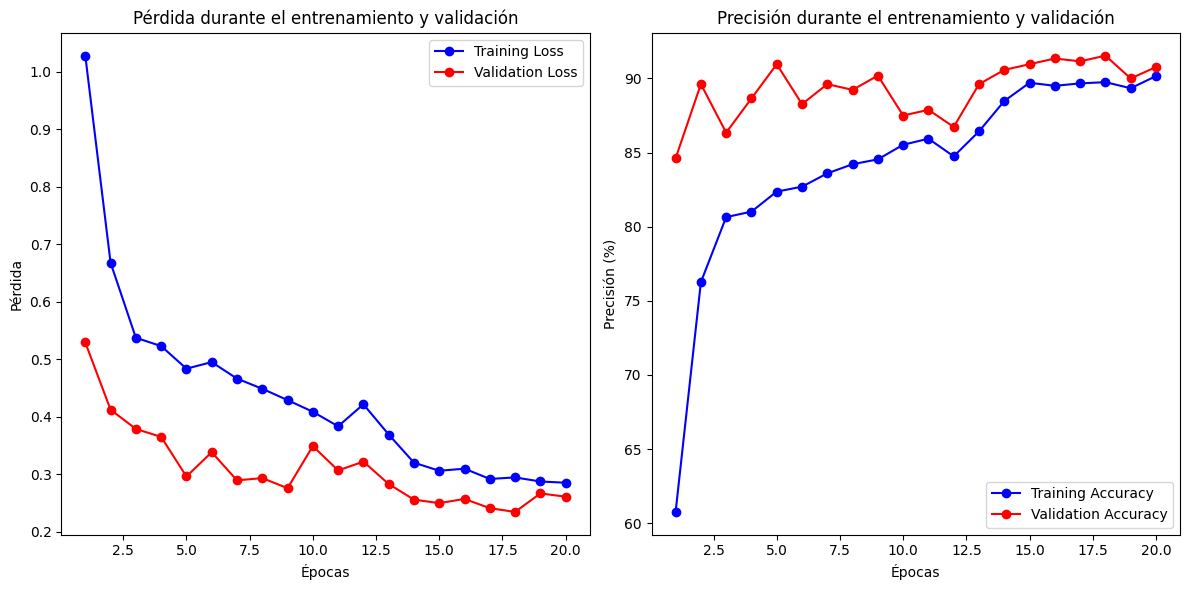

In [11]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs +1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Gráfico de Pérdida (Train y Val)
ax1.plot(epochs_range, hist_loss_train, 'b-o', label='Training Loss')
ax1.plot(epochs_range, hist_loss_val, 'r-o', label='Validation Loss')
ax1.set_title("Pérdida durante el entrenamiento y validación")
ax1.set_xlabel("Épocas")
ax1.set_ylabel("Pérdida")
ax1.legend()

# Gráfico de Precisión (Train y Val)
ax2.plot(epochs_range, [a * 100 for a in hist_acc_train], 'b-o', label='Training Accuracy')
ax2.plot(epochs_range, [a * 100 for a in hist_acc_val], 'r-o', label='Validation Accuracy')
ax2.set_title("Precisión durante el entrenamiento y validación")
ax2.set_xlabel("Épocas")
ax2.set_ylabel("Precisión (%)")
ax2.legend()

plt.tight_layout()
plt.show()

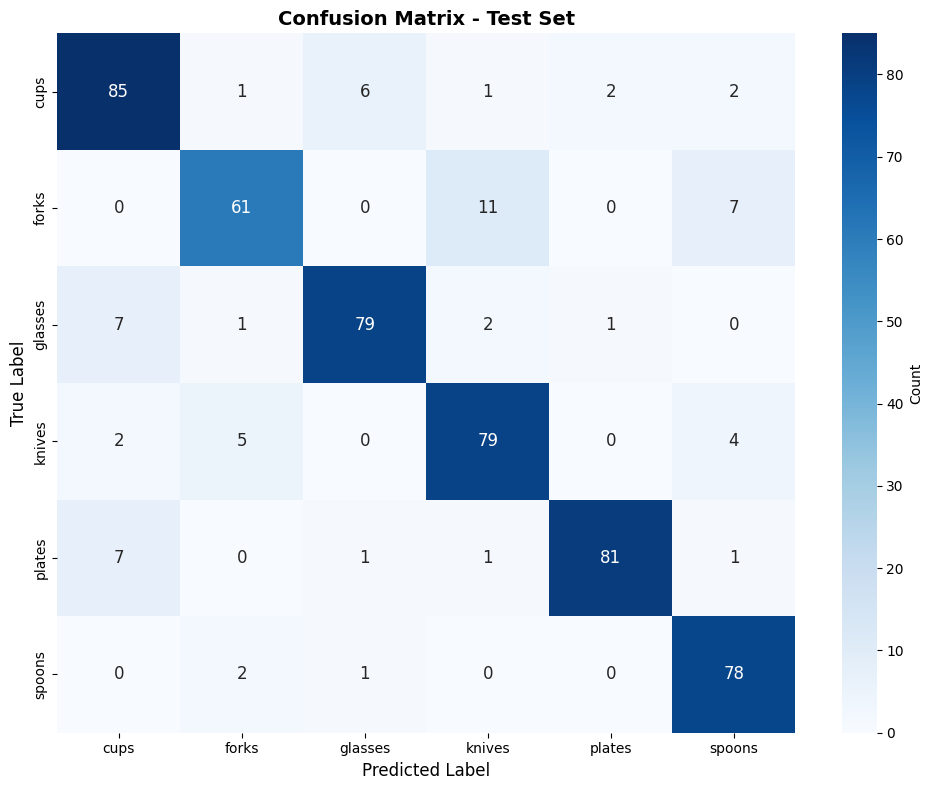

✓ Confusion Matrix guardada como 'confusion_matrix.png'

Total imágenes mal clasificadas: 65


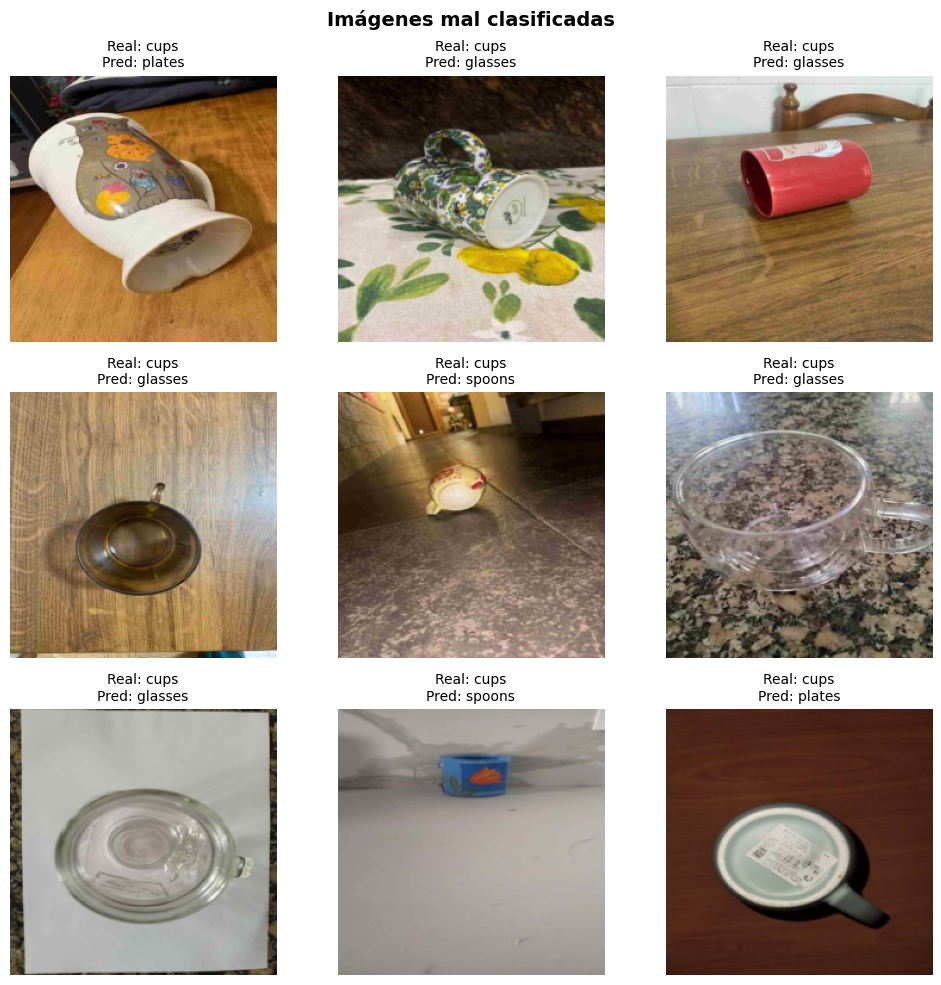

In [12]:
# ============================================================================
# FIGURA 2: CONFUSION MATRIX
# ============================================================================

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(todas_etiquetas_test, todas_predicciones_test)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            cbar_kws={'label': 'Count'}, annot_kws={'size': 12})
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Confusion Matrix guardada como 'confusion_matrix.png'")

# ── 2. IMÁGENES MAL CLASIFICADAS ─────────────────────────────────
# Buscamos índices donde la predicción fue incorrecta
errores = [(i, p, e) for i, (p, e) in enumerate(zip(todas_predicciones_test, todas_etiquetas_test)) if p != e]
print(f"\nTotal imágenes mal clasificadas: {len(errores)}")

# Mostramos las primeras 9
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for idx, (i, pred, real) in enumerate(errores[:9]):
    imagen, _ = test_dataset[i]
    # Desnormalizamos para visualizar
    mean = torch.tensor([0.485, 0.456, 0.406])
    std  = torch.tensor([0.229, 0.224, 0.225])
    imagen = imagen * std[:, None, None] + mean[:, None, None]
    imagen = imagen.permute(1, 2, 0).numpy()
    imagen = np.clip(imagen, 0, 1)

    axes[idx].imshow(imagen)
    axes[idx].set_title(f'Real: {classes[real]}\nPred: {classes[pred]}', fontsize=10)
    axes[idx].axis('off')

# Ocultamos los ejes sobrantes si hay menos de 9 errores
for idx in range(len(errores[:9]), 9):
    axes[idx].axis('off')

plt.suptitle('Imágenes mal clasificadas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('misclassified.png', dpi=150)
plt.show()

In [13]:
# ============================================================================
# RESUMEN FINAL DE EXPERIMENTO 1
# ============================================================================

print("\n" + "="*70)
print("RESUMEN FINAL - EXPERIMENTO - ResNet50 Preentrenado (Transfer Learning)")
print("="*70)

print(f"\n{'MÉTRICA':<30} {'VALIDACIÓN':<15} {'TEST':<15}")
print("-" * 60)
print(f"{'Accuracy':<30} {hist_acc_val[-1]:<15.4f} {acc_test:<15.4f}")
print(f"{'Macro F1-Score':<30}{"":<17}{f1_test:<15.4f}")
print(f"{'Training Loss (final)':<30} {hist_loss_train[-1]:<15.4f}")

print("\n" + "="*70)
print("ARCHIVOS GENERADOS")
print("="*70)
print("✓ training_curves.png")
print("✓ confusion_matrix.png")
print("✓ misclassified.png")
print("\n✓ Experimento ResNet50 Preentrenado COMPLETADO")


RESUMEN FINAL - EXPERIMENTO - ResNet50 Preentrenado (Transfer Learning)

MÉTRICA                        VALIDACIÓN      TEST           
------------------------------------------------------------
Accuracy                       0.9077          0.8769         
Macro F1-Score                                 0.8760         
Training Loss (final)          0.2852         

ARCHIVOS GENERADOS
✓ training_curves.png
✓ confusion_matrix.png
✓ misclassified.png

✓ Experimento ResNet50 Preentrenado COMPLETADO
